# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?

Разница будет заключаться в способом сжимания данных, SFA - к данным применяется Дискретное преобразование Фурье (DFT) или другой вид полиномиального сжатия, SAX - временной ряд нормализуется, делится на одинаковые интервалы, и для каждого интервала вычисляется среднее значение. SFA Будет брать первые признаки, откидывая выбросы (которые выглядят как высокочастнотные колебания), оставляя низкочастотные, в которых больше полезных данных. В SAX  временной ряд нормализируется, делится на одинаковые интервалы и для каждого находится среднее значение, не зависимо есть ли там выбросы или нет, что вызвает ложное срабатывание.

2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?

Алгоритмы BOSS адаптируют классическую концепцию TF-IDF из обработки текстов для анализа временных рядов, рассматривая каждый временной ряд как «документ», а дискретные паттерны (символы) — как «слова». Смысл заключается в том, что алгоритм отфильтровывает фоновый шум и общие паттерны, выступает в роли сглаживания и является быстрым и "компактным" из-за работы с разреженными матрицами.

3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?

Это характерные, легко различимые фрагменты (подпоследовательности) временного ряда, которые выступают в роли мощных индикаторов. ROCKET, вместо направленного поиска конкретных идеальных фрагментов,применяет огромное количество случайных сверточных ядер, что делает скорость высокой, наборы богатыми (из-за вариации ядер), давая высокую точность и малые требования ресурсов.

4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?

Если выборка малая, то это удобнее. Для обучения CNN необходимы миллионы примеров, чтобы сеть не переобучалась. Так же добавляется сюда ресурсоемкость и устойчивость к шуму.

5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

Они устойчивы к сдвигам, быстро обучаются и не требуют последовательного вычисления состояний, что дает возможность быстро распараллеливать их. Архитектура InceptionTime адаптирует принципы зрительных сетей для анализа одномерных данных. В основе ее модуля лежит параллельная обработка входного сигнала.

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


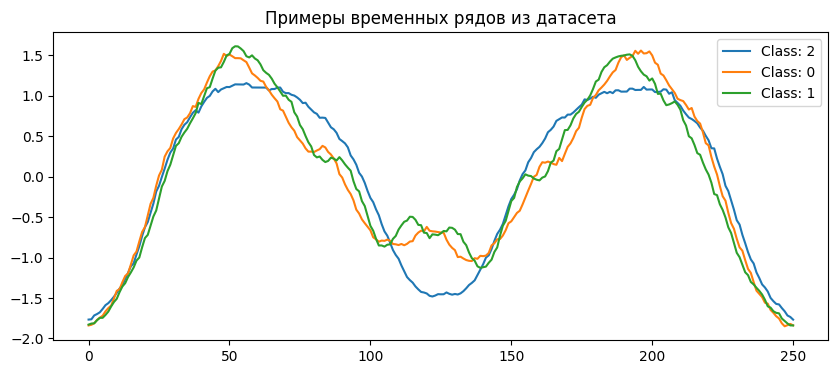

In [ ]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [ ]:
from sktime.classification.kernel_based import RocketClassifier
import time

rocket = RocketClassifier()

start_time = time.time()
rocket.fit(X_train, y_train)
train_time_rocket = time.time() - start_time

y_pred_rocket = rocket.predict(X_test)

acc_rocket = accuracy_score(y_test, y_pred_rocket)

print("ROCKET Accuracy:", acc_rocket)
print("ROCKET Training time:", train_time_rocket)



### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [ ]:
from sktime.classification.dictionary_based import ContractableBOSS
from sklearn.metrics import accuracy_score
import time

boss = ContractableBOSS(random_state=42, n_parameter_samples=10, max_ensemble_size=5)

# Замер времени обучения
start_time = time.time()
boss.fit(X_train, y_train)
train_time_boss = time.time() - start_time

# Предсказание
y_pred_boss = boss.predict(X_test)
accuracy_boss = accuracy_score(y_test, y_pred_boss)

print(f"Время обучения BOSS: {train_time_boss:.2f} секунд")
print(f"Точность (Accuracy) на тестовой выборке: {accuracy_boss:.4f}")

# Сравнение времени с ROCKET 
print(f"Время ROCKET: {train_time_rocket:.2f} сек")
print(f"BOSS медленнее ROCKET в {train_time_boss / train_time_rocket:.1f} раз")

    

### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [ ]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
from sklearn.metrics import accuracy_score

# Подготовка данных для PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

# Определение модели 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, 3)
        self.pool2 = nn.MaxPool1d(2)
        self.fc1 = nn.Linear(64 * 61, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

# Инициализация
model = Simple1DCNN(len(set(y_train)))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение
start = time.time()
for epoch in range(20):
    model.train()
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
    # Оценка после эпохи
    model.eval()
    correct = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            pred = model(Xb).argmax(1)
            correct += (pred == yb).sum().item()
    print(f"Epoch {epoch+1}, test acc: {correct / len(test_loader.dataset):.4f}")

train_time = time.time() - start

# Финальная точность
model.eval()
preds = []
with torch.no_grad():
    for Xb, _ in test_loader:
        preds.extend(model(Xb).argmax(1).cpu().numpy())
acc_cnn = accuracy_score(y_test, preds)
print(f"\n1D-CNN Accuracy: {acc_cnn:.4f}, время: {train_time:.2f} сек")